![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# **01 | Exploratory Data Analysis**

### *Project 1 — SQL: From Data to Insight*

## **Team:** **Bright Jaato**

## **Dataset:** **CO<sub>2</sub> Reduction Electrocatalyst Dataset — Malek et al. (2021)**

---

Understanding your data before you design anything. You cannot decide which tables you need until you know which columns repeat, which are broken, and which identify a row.

> **Done when:** you can name the 3+ tables you are going to build, you have written down at least 2 research questions, and you know every data-quality problem notebook 02 will have to fix.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

## **Project goal**

The goal of this exploratory data analysis (EDA) is to understand the structure, quality, and key patterns in a published CO<sub>2</sub> electroreduction dataset before cleaning, relational database design, and SQL analysis.

The analysis will determine what the data can reliably answer, identify data-quality issues, refine the research questions, and inform the database structure used later in the project.

## **Dataset source**

The dataset is supplementary data from:

**Malek et al. (2021), "A Data-Driven Framework for the Accelerated Discovery of CO<sub>2</sub> Reduction Electrocatalysts."**  *Frontiers in Energy Research, 9, 609070.*  DOI: [10.3389/fenrg.2021.609070](https://doi.org/10.3389/fenrg.2021.609070)

The dataset is publicly available under the CC BY 4.0 licence.

The excel workbook contains:

- a low-temperature CO<sub>2</sub> reduction reaction (CO<sub>2</sub>RR) experimental data block,

- a second CO<sub>2</sub>RR experimental data block containing different variables and a broad range of reported temperatures,

- catalyst ranking/recommendation results.

The two experimental data blocks are explored separately because they contain different variables and represent different reported experimental conditions.

---
## **0. Setup**

### **Purpose**

The raw Excel workbook is loaded without modifying the source file.

The workbook contains multiple data blocks on a single worksheet, so the first step is to inspect the worksheet structure before extracting the low-temperature CO₂RR data block and the second experimental CO<sub>2</sub>RR data block into separate DataFrames.

No cleaning or transformation is performed at this stage.

### **Libraries and setup**

The libraries below are used throughout the EDA:

- **pandas** for loading, inspecting, and manipulating tabular data,
- **NumPy** for numerical operations,
- **Matplotlib** and **Seaborn** for data visualisation,
- **src.functions** for reusable project functions.

The pandas display setting is adjusted to show more columns when inspecting wide datasets.

In [1]:
#Import Python's system tools so we can adjust where Python looks for files.
import sys

#Add the project root folder so the notebook can access the src/ folder.
sys.path.append("..")          # so `src` is importable from inside notebooks/

#Import pandas for loading, inspecting, and manipulating tabular data.
#Import NumPy for numerical operations.
#Import Matplotlib for creating plots and charts.
#Import Seaborn for statistical visualisations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Allow pandas to display up to 100 columns when inspecting wide DataFrames.
pd.set_option("display.max_columns", 100)

#Use a clean plotting style with grid lines for easier reading.
sns.set_theme(style="whitegrid")

---
## **1. Load the raw data**

### **Purpose**

The raw Excel workbook is loaded from the `data/raw/` folder.

Because the workbook contains multiple logical data blocks on a single worksheet, the first step is to inspect the worksheet structure before loading the two CO<sub>2</sub>RR experimental data blocks separately.

The raw source file remains unchanged.

In [2]:
# Import Path so file paths can be handled clearly and consistently.
from pathlib import Path

# Define the location of the original raw Excel workbook.
file_path = Path("../data/raw/Data Sheet.xlsx")

# Open the workbook without loading a specific worksheet into a DataFrame.
excel_file = pd.ExcelFile(file_path)

# Inspect the worksheet names available in the workbook.
excel_file.sheet_names

['Sheet1']

### **Inspect the worksheet layout**

The workbook contains one worksheet, `Sheet1`. Since the worksheet contains several data blocks placed side by side, it is loaded without assigning column headers first.

This allows the raw row and column structure to be inspected before deciding which ranges belong to the first and second CO<sub>2</sub>RR experimental data blocks.

In [3]:
# Load the worksheet exactly as it appears, without treating any row as the column header.
raw_sheet = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    header=None
)

# Display the first rows so the layout of the different data blocks can be inspected.
raw_sheet.head(15)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,Supplementary Table 1. Sample of data for mat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Supplementary Table 2. Sample of data for mat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Supplementary Table 2. Sample of optimized and...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,Catalyst,Product,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr),NaN,NaN,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product,T (oC),NaN,NaN,Ranks,Catalyst,Product,Cost,Applied Potential,Faradaic Efficiency,Current Density,Selectivity,Production Rate
4,NaN,NaN,NaN,NaN,Cu,CO,1477.418,-0.68548,48.37736,685.9154,75.96904,5606.265,NaN,NaN,Ni-YSZ,NaN,0.610727,100,YSZ,CO,850,NaN,NaN,0,Best,Best,1,1,1,1,1,1
5,NaN,NaN,NaN,NaN,Pd,HCOOH,3189.148,-1.13664,2.602357,203.6676,85.23544,3545.383,NaN,NaN,Ni-YSZ,NaN,66.969819,100,YSZ,CO,850,NaN,NaN,1,Ag,HCOOH,0.92637,0.894479,0.941514,0.905183,0.595532,0.771946
6,NaN,NaN,NaN,NaN,Pt,CO,5169.764,-2.26996,92.88387,871.1595,1.876306,9569.314,NaN,NaN,Ni-YSZ,NaN,133.640737,100,YSZ,CO,850,NaN,NaN,2,Au,CH4,0.951446,0.933677,0.945833,0.613838,0.645478,0.888081
7,NaN,NaN,NaN,NaN,C,HCOOH,8467.83,-1.57404,95.45173,215.0477,45.15711,5870.475,NaN,NaN,Ni-YSZ,NaN,227.754773,100,YSZ,CO,850,NaN,NaN,3,C,H2,0.800014,0.868167,0.840484,0.831275,0.785005,0.939159
8,NaN,NaN,NaN,NaN,Pd,HCOOH,9688.819,-3.85536,70.35596,339.4034,37.26586,324.7051,NaN,NaN,Ni-YSZ,NaN,312.07282,100,YSZ,CO,850,NaN,NaN,4,Au,HCOOH,0.892998,0.866823,0.986473,0.604088,0.935932,0.602346
9,NaN,NaN,NaN,NaN,Au,CH4,5281.501,-2.77461,83.64851,283.837,34.21728,8785.877,NaN,NaN,Ni-YSZ,NaN,376.77896,100,YSZ,CO,850,NaN,NaN,5,Sn,H2,0.815252,0.918802,0.889583,0.726932,0.890785,0.631203


### **Initial observation**

The worksheet contains separate experimental data blocks placed side by side.

- The low-temperature CO<sub>2</sub>RR data block is located in columns E:L.
- The second CO<sub>2</sub>RR experimental data block is located in columns O:U.
- The column headers for both data blocks begin on Excel row 4.
- Rows above the headers contain descriptive text rather than experimental observations.

The two experimental data blocks will therefore be loaded separately for further exploration.

In [4]:
# Now create the two DataFrames directly from the original workbook
# Load only the low-temperature columns.
# Use row 4 of the Excel worksheet as the column names.
low_temp_df = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    usecols="E:L",
    header=3
)

# Load only the second experimental data block.
# Use row 4 of the Excel worksheet as the column names.
high_temp_df = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    usecols="O:U",
    header=3
)

In [5]:
# Display the first five low-temperature observations.
low_temp_df.head()

,Catalyst,Product,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr)
0,Cu,CO,1477.418,-0.68548,48.377360,685.9154,75.969040,5606.2650
1,Pd,HCOOH,3189.148,-1.13664,2.602357,203.6676,85.235440,3545.3830
2,Pt,CO,5169.764,-2.26996,92.883870,871.1595,1.876306,9569.3140
3,C,HCOOH,8467.830,-1.57404,95.451730,215.0477,45.157110,5870.4750
4,Pd,HCOOH,9688.819,-3.85536,70.355960,339.4034,37.265860,324.7051


In [6]:
# Display the first five observations in the second experimental dataset.
high_temp_df.head()

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)
0,Ni-YSZ,NaN,0.610727,100.0,YSZ,CO,850
1,Ni-YSZ,NaN,66.969819,100.0,YSZ,CO,850
2,Ni-YSZ,NaN,133.640737,100.0,YSZ,CO,850
3,Ni-YSZ,NaN,227.754773,100.0,YSZ,CO,850
4,Ni-YSZ,NaN,312.072820,100.0,YSZ,CO,850


### **Observation**

The two CO<sub>2</sub>RR experimental data blocks were successfully loaded as separate DataFrames.

The low-temperature dataset contains variables related to:
- catalyst,
- product,
- cost,
- applied potential,
- Faradaic efficiency,
- current density,
- selectivity,
- and production rate.

The second experimental dataset contains variables related to:
- catalyst,
- voltage,
- total current density,
- Faradaic efficiency,
- electrolyte,
- product,
- and temperature.

Some missing values are already visible in the voltage column of the second dataset.

The product column in the second dataset was imported as `Product.1`, which will be reviewed and standardised during data cleaning.

#### **Note on scientific formatting**

Some superscript and subscript formatting used in the original Excel headers is not preserved when the worksheet is imported with pandas.

For example, units such as `mA/cm<sup>2<\sup>`, `m<sup>3</sup>/hr`, `CO<sub>2</sub>`, and `oC` may appear in the imported column names as `mA/cm2`, `m3/hr`, `CO2`, and `oC`.

The scientifically correct notation is used in the notebook text and visualisations, while the cleaned column names will be standardised in Notebook 02.

---
## **2. First look**

Shape, column types, a handful of rows. What is one row of this data?

### **2.1 Low-temperature dataset**
#### **2.1.a Shape**

First, inspect the overall shape of the low-temperature dataset.

In [7]:
# Check the number of rows and columns in the low-temperature dataset.
low_temp_df.shape

(181, 8)

#### **Observation**

The imported low-temperature DataFrame contains **181 rows and 8 columns**.

However, the raw shape alone does not confirm that all 181 rows contain experimental data. Because the two data blocks in the original worksheet extend to different row positions, the extracted column range may include trailing empty rows.

The number of populated rows is therefore verified below.

#### ***Row-count verification***

Next, verify how many extracted rows contain experimental data and how many are completely empty.

In [8]:
# Count how many rows contain at least one non-missing value.
low_temp_populated_rows = low_temp_df.notna().any(axis=1).sum()

low_temp_populated_rows

101

In [9]:
# Count rows where every column is missing.
low_temp_empty_rows = low_temp_df.isna().all(axis=1).sum()

low_temp_empty_rows

80

#### **Observation**

Of the 181 extracted rows, **101 contain experimental data** and **80 are completely empty**.

The 80 empty rows are trailing rows created by the worksheet layout rather than partially missing experimental records.

Therefore, the low-temperature dataset contains **101 populated observations**. The completely empty rows will be removed during data cleaning in Notebook 02.

#### **2.1.b Column names and data types**

Next, inspect the column names, data types, and non-null counts.

In [10]:
# Display the column names, data types,
# and number of non-null values in each column.
low_temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Catalyst                  101 non-null    object 
 1   Product                   101 non-null    object 
 2   Cost ($/tCO2)             101 non-null    float64
 3   Applied Potential (V)     101 non-null    float64
 4   Faradaic Efficiency (%)   101 non-null    float64
 5   Current Density (mA/cm2)  101 non-null    float64
 6   Selectivity               101 non-null    float64
 7   Production Rate (m3/hr)   101 non-null    float64
dtypes: float64(6), object(2)
memory usage: 11.4+ KB


#### **Observation**

The low-temperature dataset contains two categorical columns, `Catalyst` and `Product`, which are stored as text (`object`).

The remaining six columns contain numerical measurements and are stored as floating-point values (`float64`).

Each column contains 101 non-null values, which matches the 101 populated experimental rows identified above.

This indicates that the populated records are complete across all eight variables, while the remaining 80 extracted rows are entirely empty.

### **2.1.c Sample rows**

The low-temperature block contains completely empty trailing rows.

Before inspecting the data, remove only rows where all values are missing.

In [11]:
# 1. Start from the raw low-temperature DataFrame.
# 2. Remove rows where every value is missing.
# 3. Save the populated rows in a new DataFrame for EDA.

low_temp_non_empty = low_temp_df.dropna(how="all")

Next, inspect a small sample of populated rows to understand how the variables are organised within each observation.

In [12]:
# Display the first five populated rows
# to inspect the values and structure of the dataset.
low_temp_non_empty.head()

,Catalyst,Product,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr)
0,Cu,CO,1477.418,-0.68548,48.377360,685.9154,75.969040,5606.2650
1,Pd,HCOOH,3189.148,-1.13664,2.602357,203.6676,85.235440,3545.3830
2,Pt,CO,5169.764,-2.26996,92.883870,871.1595,1.876306,9569.3140
3,C,HCOOH,8467.830,-1.57404,95.451730,215.0477,45.157110,5870.4750
4,Pd,HCOOH,9688.819,-3.85536,70.355960,339.4034,37.265860,324.7051


#### **Observation**

The sample rows show that each record combines a catalyst and a reported CO<sub>2</sub>RR product with several performance-related variables.

For example, the dataset contains catalyst–product combinations such as Cu–CO, Pd–HCOOH, and Pt–CO.

The numerical columns provide information on cost, applied potential, Faradaic efficiency, current density, selectivity, and production rate.

The sample confirms that the populated rows are structured consistently and that the dataset contains multiple catalyst–product combinations suitable for later comparison.

#### **2.1.d What does one row represent?**

Each populated row in the low-temperature dataset represents one reported CO<sub>2</sub>RR observation for a specific catalyst–product combination.

The row links that catalyst and product to the corresponding reported values for cost, applied potential, Faradaic efficiency, current density, selectivity, and production rate.

Therefore, one row can be understood as one literature-derived experimental record describing the reported performance of a catalyst for a particular CO₂RR product under the conditions represented in the source dataset.

### **2.2 Second experimental dataset**
#### **2.2.a Shape**

First, inspect the overall shape of the second experimental dataset.

In [13]:
# Check the number of rows and columns in the second experimental dataset.
high_temp_df.shape

(181, 7)

#### **Observation**

The second experimental DataFrame contains **181 rows and 7 columns**.

Unlike the low-temperature dataset, all 181 rows contain at least one reported value, so there are no completely empty trailing rows in this data block.

#### **Row-count verification**

Next, verify whether all extracted rows contain experimental information.

In [14]:
# Count rows containing at least one value.
second_populated_rows = high_temp_df.notna().any(axis=1).sum()

# Count rows where every value is missing.
second_empty_rows = high_temp_df.isna().all(axis=1).sum()

second_populated_rows, second_empty_rows

(181, 0)

#### **Observation**

All **181 rows are populated**, and there are **0 completely empty rows**.

This means the full extracted row range contains experimental records, although some individual variables may still contain missing values.

#### **2.2.b Column names and data types**

Next, inspect the column names, data types, and non-null counts.

In [15]:
# Display the column names in the second experimental dataset.
high_temp_df.columns

Index(['Catalysts', 'Voltage(V)', 'Jtot(mA/cm2)', 'FE  (%)', 'Electrolyte',
       'Product.1', 'T (oC)'],
      dtype='object')

In [16]:
# Show the data type of each column
# and how many non-missing values each column contains.
high_temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Catalysts     181 non-null    object 
 1   Voltage(V)    76 non-null     float64
 2   Jtot(mA/cm2)  181 non-null    float64
 3   FE  (%)       105 non-null    float64
 4   Electrolyte   181 non-null    object 
 5   Product.1     181 non-null    object 
 6   T (oC)        181 non-null    int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 10.0+ KB


#### **Observation**

The second experimental dataset contains seven variables.

`Catalysts`, `Electrolyte`, and `Product.1` are stored as text (`object`) because they contain categorical information.

`Voltage(V)`, `Jtot(mA/cm2)`, and `FE  (%)` are stored as floating-point numerical values (`float64`).

`T (oC)` is stored as an integer (`int64`) because the reported temperature values are whole numbers.

The data types are appropriate for the variables represented in the dataset.

The non-null counts also show that `Voltage(V)` and `FE  (%)` contain missing values, while the remaining variables are complete.

The imported column name `Product.1` and inconsistent spacing in `FE  (%)` will be reviewed and standardised during data cleaning in Notebook 02.

#### **2.2.c Sample rows**

Next, inspect a small sample of rows to understand how the variables are organised within each observation.

In [17]:
# Display the first five rows
# to inspect the structure and reported values.
high_temp_df.head()

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)
0,Ni-YSZ,NaN,0.610727,100.0,YSZ,CO,850
1,Ni-YSZ,NaN,66.969819,100.0,YSZ,CO,850
2,Ni-YSZ,NaN,133.640737,100.0,YSZ,CO,850
3,Ni-YSZ,NaN,227.754773,100.0,YSZ,CO,850
4,Ni-YSZ,NaN,312.072820,100.0,YSZ,CO,850


#### **Observation**

The sample rows show repeated measurements for the same catalyst, electrolyte, product, and temperature while total current density changes across observations.

In the first five rows:
- the catalyst is `Ni-YSZ`,
- the electrolyte is `YSZ`,
- the product is `CO`,
- the temperature is `850 °C`,
- Faradaic efficiency is reported as `100%`,
- total current density varies across the rows,
- voltage is missing (`NaN`) for these observations.

This suggests that multiple rows may describe the same catalyst system under similar reported conditions but at different measured current densities.

#### **2.2.d What does one row represent?**

Each row in the second experimental dataset represents one reported CO<sub>2</sub>RR observation for a particular catalyst system under a specific set of reported conditions.

The row links the catalyst to:
- voltage, where reported,
- total current density,
- Faradaic efficiency, where reported,
- electrolyte,
- product,
- and temperature.

Multiple rows may therefore belong to the same catalyst–electrolyte–product system while differing in measured current density or in which performance variable is reported.

One row is best understood as one literature-derived experimental record from the second CO<sub>2</sub>RR data block.

---
## **3. Data quality**

Missing values, duplicates, numbers stored as text, dates stored as strings. Write down what you find — this is the to-do list for notebook 02.

### **3.1 Low-temperature dataset**

#### **3.1.a Missing values**

First, examine the extent of missing data in each variable.

In [18]:
# Count missing values in each column of the imported low-temperature DataFrame.
low_temp_df.isna().sum()

Catalyst                    80
Product                     80
Cost ($/tCO2)               80
Applied Potential (V)       80
Faradaic Efficiency (%)     80
Current Density (mA/cm2)    80
Selectivity                 80
Production Rate (m3/hr)     80
dtype: int64

Next, repeat the missing-value check using only the populated experimental records.

In [19]:
# Temporarily remove rows where every column is empty.
low_temp_non_empty = low_temp_df.dropna(how="all")

# Count missing values again within the actual populated experimental records.
low_temp_non_empty.isna().sum()

Catalyst                    0
Product                     0
Cost ($/tCO2)               0
Applied Potential (V)       0
Faradaic Efficiency (%)     0
Current Density (mA/cm2)    0
Selectivity                 0
Production Rate (m3/hr)     0
dtype: int64

#### **Observation**

The initial missing-value check reports **80 missing values in every column**.

These missing values correspond exactly to the **80 completely empty trailing rows** identified earlier and do not represent partially missing experimental observations.

After excluding rows where every column is empty, the remaining **101 populated low-temperature observations contain no missing values** across the eight variables.

Therefore, the low-temperature experimental records are complete with respect to the variables included in this dataset.

The 80 completely empty rows will be removed during data cleaning in Notebook 02.

#### **3.1.b Duplicates**

Next, check whether any populated experimental records are exact duplicates.

In [20]:
# Count exact duplicate rows among the 101 populated low-temperature observations.

low_temp_duplicates = low_temp_non_empty.duplicated().sum()

low_temp_duplicates

0

Then inspect any duplicated rows directly.

In [21]:
# Display all rows involved in exact duplicates, if any.
low_temp_non_empty[
    low_temp_non_empty.duplicated(keep=False)
]

,Catalyst,Product,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr)


#### **Observation**

No exact duplicate rows were found among the **101 populated low-temperature observations**.

The duplicate count is **0**, and the duplicate inspection returns an empty DataFrame.

This indicates that each populated row is unique across the eight variables included in the dataset.

Therefore, no duplicate removal is required for the low-temperature dataset at this stage.

#### **3.1.c Categorical consistency**

Next, inspect the categorical variables for possible formatting inconsistencies.

In [22]:
# Display the unique catalyst labels used in the low-temperature dataset.
low_temp_non_empty["Catalyst"].unique()

array(['Cu', 'Pd', 'Pt', 'C', 'Au', 'Sn', 'Ir', 'Ag'], dtype=object)

In [23]:
# Display the unique product labels used in the low-temperature dataset.
low_temp_non_empty["Product"].unique()

array(['CO', 'HCOOH', 'CH4', 'H2', 'C2H5OH'], dtype=object)

Next, inspect the frequency of each categorical value.

In [24]:
# Count how many observations belong to each catalyst category.
low_temp_non_empty["Catalyst"].value_counts()

Catalyst
Pt    19
Ag    18
Cu    15
Pd    14
C     12
Au     8
Sn     8
Ir     7
Name: count, dtype: int64

In [25]:
# Count how many observations belong to each product category.
low_temp_non_empty["Product"].value_counts()

Product
CO        26
H2        23
HCOOH     21
CH4       18
C2H5OH    13
Name: count, dtype: int64

#### **Observation**

The low-temperature dataset contains **8 catalyst categories** and **5 product categories**.

The catalyst labels are:
`Cu`, `Pd`, `Pt`, `C`, `Au`, `Sn`, `Ir`, and `Ag`.

The product labels are:
`CO`, `HCOOH`, `CH4`, `H2`, and `C2H5OH`.

No obvious inconsistencies such as leading/trailing whitespace, alternative spellings, or duplicated labels are visible in these categorical values.

The repeated catalyst and product categories may later support separate lookup tables in the relational database.

#### **3.1.d Numerical summary and range**

Next, summarise the numerical variables to examine their ranges and identify potentially unusual values.

In [26]:
# Generate summary statistics for the numerical columns in the populated low-temperature dataset.
low_temp_non_empty.describe()

,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr)
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,5067.352682,-2.137901,55.941001,487.662409,50.017945,5319.208939
std,2901.137991,1.090022,28.342258,289.160140,28.855982,2820.882756
min,174.953100,-3.985940,2.462711,14.832530,0.147268,130.234500
25%,2944.993000,-3.042350,32.418720,226.653000,27.286210,3456.950000
50%,4948.548000,-2.088020,55.508050,483.173200,52.880850,5635.836000
75%,7433.420000,-1.303700,83.691150,719.812100,73.651340,7577.744000
max,9960.076000,-0.084690,99.832400,994.839900,99.924570,9981.328000


#### **Observation**

The numerical variables span broad ranges across the 101 populated low-temperature observations.

Faradaic efficiency and selectivity remain within the expected percentage range of 0–100%.

Current density, cost, applied potential, and production rate vary substantially across the dataset, indicating that the observations represent a wide variety of reported catalyst–product conditions rather than one narrow experimental setting.

The summary statistics are useful as a general data-quality check, but they should not be interpreted as direct catalyst comparisons because the dataset combines different catalysts, products, and reported experimental conditions.

#### **3.1.e Basic numerical validity checks**

Finally, apply simple numerical validity checks to identify values outside expected limits.

In [27]:
# Find rows where Faradaic efficiency falls outside 0–100%.
low_temp_non_empty[
    (low_temp_non_empty["Faradaic Efficiency (%)"] < 0) |
    (low_temp_non_empty["Faradaic Efficiency (%)"] > 100)
]

,Catalyst,Product,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr)


In [28]:
# Find rows where selectivity falls outside 0–100%.
low_temp_non_empty[
    (low_temp_non_empty["Selectivity"] < 0) |
    (low_temp_non_empty["Selectivity"] > 100)
]

,Catalyst,Product,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr)


In [29]:
# Find rows with zero or negative current density values.
low_temp_non_empty[
    low_temp_non_empty["Current Density (mA/cm2)"] <= 0
]

,Catalyst,Product,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr)


#### **Observation**

No obvious invalid numerical values were identified by these basic checks.

All Faradaic efficiency values fall within **0–100%**, all selectivity values fall within **0–100%**, and all reported current-density values are positive.

These checks support the numerical consistency of the populated low-temperature records, although they do not by themselves confirm the scientific plausibility of every observation.

### **3.2 Second experimental dataset**

#### **3.2.a Missing values**

First, examine the extent of missing data in each variable.

In [30]:
# Count missing values in each column
# of the second experimental dataset.
high_temp_df.isna().sum()

Catalysts         0
Voltage(V)      105
Jtot(mA/cm2)      0
FE  (%)          76
Electrolyte       0
Product.1         0
T (oC)            0
dtype: int64

Next, calculate the percentage of missing values in each variable.

In [31]:
# Calculate the percentage of missing values
# in each column of the second experimental dataset.
high_temp_df.isna().mean() * 100

Catalysts        0.00000
Voltage(V)      58.01105
Jtot(mA/cm2)     0.00000
FE  (%)         41.98895
Electrolyte      0.00000
Product.1        0.00000
T (oC)           0.00000
dtype: float64

#### **Observation**

Missing values are concentrated in two numerical variables: `Voltage(V)` and `FE  (%)`.

- `Voltage(V)` is missing in **105 of 181 observations** (about **58.0%**).
- `FE  (%)` is missing in **76 of 181 observations** (about **42.0%**).
- All other variables are complete.

Because the missing values occur only in these two columns, their pattern should be examined before deciding whether any rows should be removed or values should be imputed.

#### **3.2.b Missing-value pattern**

Next, examine whether the missing values in voltage and Faradaic efficiency follow a systematic pattern.

In [32]:
# Count rows where voltage is missing but Faradaic efficiency is present.
voltage_missing_fe_present = (
    high_temp_df["Voltage(V)"].isna() &
    high_temp_df["FE  (%)"].notna()
).sum()

voltage_missing_fe_present

105

In [33]:
# Count rows where Faradaic efficiency is missing but voltage is present.
fe_missing_voltage_present = (
    high_temp_df["FE  (%)"].isna() &
    high_temp_df["Voltage(V)"].notna()
).sum()

fe_missing_voltage_present

76

In [34]:
# Count rows where both voltage and Faradaic efficiency are missing.
both_missing = (
    high_temp_df["Voltage(V)"].isna() &
    high_temp_df["FE  (%)"].isna()
).sum()

both_missing

0

In [35]:
# Count rows where both voltage and Faradaic efficiency are reported.
both_present = (
    high_temp_df["Voltage(V)"].notna() &
    high_temp_df["FE  (%)"].notna()
).sum()

both_present

0

#### **Observation**

The missing values in `Voltage(V)` and `FE  (%)` follow a clear complementary pattern.

- **105 observations** contain Faradaic efficiency but no voltage.
- **76 observations** contain voltage but no Faradaic efficiency.
- **0 observations** are missing both variables.
- **0 observations** contain both variables.

This shows that every record reports either voltage or Faradaic efficiency, but never both.

The missingness is therefore structured rather than randomly distributed across the dataset. These values should not be automatically dropped or imputed without first considering how the source data were reported.

#### ****Data-quality note**

The Faradaic efficiency column contains inconsistent spacing in its name (`FE  (%)`). This will be standardized during data cleaning.

#### **3.2.c Duplicates**

Next, check whether any experimental records are exact duplicates.

In [36]:
# Count exact duplicate rows
# in the second experimental dataset.
second_duplicates = high_temp_df.duplicated().sum()

second_duplicates

0

Then inspect any duplicated rows directly.

In [37]:
# Display all rows involved in exact duplicates, if any.
high_temp_df[
    high_temp_df.duplicated(keep=False)
]

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)


#### **Observation**

No exact duplicate rows were found among the **181 observations** in the second experimental dataset.

The duplicate count is **0**, and the duplicate inspection returns an empty DataFrame.

This indicates that each row is unique across the seven variables included in the dataset.

Therefore, no duplicate removal is required for this dataset at this stage.

#### **3.2.d Categorical consistency**

Next, inspect the categorical variables for repeated labels and possible formatting inconsistencies.

In [38]:
# Display the unique catalyst labels in the second experimental dataset.
high_temp_df["Catalysts"].unique()

array([' Ni-YSZ', 'Ni-YSZ', 'Ti', 'Ag/C', 'Ag', 'Ag-C',
       'Au-MWCNT-PyPBI-Nafion-C', 'Ag-MWCNT-Nafion'], dtype=object)

In [39]:
# Display the unique electrolyte labels.
high_temp_df["Electrolyte"].unique()

array([' YSZ', ' CGO-YSZ', ' Li2O-Li2CO3', '  KOH-Nafion-K2SO4',
       ' KHCO3-Sustanion-PTFE', ' KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3', ' KOH'],
      dtype=object)

In [40]:
# Display the unique product labels.
high_temp_df["Product.1"].unique()

array([' CO'], dtype=object)

Next, inspect the frequency of each categorical value.

In [41]:
# Count how many observations belong to each catalyst label.
high_temp_df["Catalysts"].value_counts()

Catalysts
Ti                         41
Ni-YSZ                     35
 Ni-YSZ                    26
Ag                         24
Ag/C                       22
Au-MWCNT-PyPBI-Nafion-C    18
Ag-MWCNT-Nafion            12
Ag-C                        3
Name: count, dtype: int64

In [42]:
# Count how many observations belong to each electrolyte label.
high_temp_df["Electrolyte"].value_counts()

Electrolyte
Li2O-Li2CO3                      41
YSZ                              39
KOH                              30
KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3    24
CGO-YSZ                          22
KHCO3-Sustanion-PTFE             13
 KOH-Nafion-K2SO4                12
Name: count, dtype: int64

In [43]:
# Count how many observations belong to each product label.
high_temp_df["Product.1"].value_counts()

Product.1
CO    181
Name: count, dtype: int64

Finally, verify whether the categorical labels contain hidden leading or trailing whitespace.

In [44]:
# Show catalyst labels exactly as stored, including hidden leading or trailing spaces.
[repr(value) for value in high_temp_df["Catalysts"].unique()]

["' Ni-YSZ'",
 "'Ni-YSZ'",
 "'Ti'",
 "'Ag/C'",
 "'Ag'",
 "'Ag-C'",
 "'Au-MWCNT-PyPBI-Nafion-C'",
 "'Ag-MWCNT-Nafion'"]

In [45]:
# Show electrolyte labels exactly as stored, including hidden leading or trailing spaces.
[repr(value) for value in high_temp_df["Electrolyte"].unique()]

["' YSZ'",
 "' CGO-YSZ'",
 "' Li2O-Li2CO3'",
 "'  KOH-Nafion-K2SO4'",
 "' KHCO3-Sustanion-PTFE'",
 "' KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3'",
 "' KOH'"]

#### **Observation**

The categorical columns contain repeated catalyst, electrolyte, and product labels.

The catalyst labels include an inconsistency caused by leading or trailing whitespace. In particular, visually identical catalyst names such as `Ni-YSZ` can appear as separate categories when one label contains an extra space.

The electrolyte labels also contain leading whitespace, although this does not necessarily create additional distinct categories.

The product column contains only one category, `CO`, across all 181 observations.

These formatting issues should be corrected during data cleaning by removing unnecessary leading and trailing whitespace from categorical values.

Chemically different labels such as `Ag`, `Ag/C`, and `Ag-C` should not be merged unless there is clear scientific justification that they represent the same catalyst system.

##### **Exact categorical label verification**

In [46]:
# Show the exact representation of each catalyst label,
# including hidden leading or trailing spaces.
[repr(value) for value in high_temp_df["Catalysts"].unique()]

["' Ni-YSZ'",
 "'Ni-YSZ'",
 "'Ti'",
 "'Ag/C'",
 "'Ag'",
 "'Ag-C'",
 "'Au-MWCNT-PyPBI-Nafion-C'",
 "'Ag-MWCNT-Nafion'"]

In [47]:
# Show the exact representation of each electrolyte label,
# including hidden leading or trailing spaces.
[repr(value) for value in high_temp_df["Electrolyte"].unique()]

["' YSZ'",
 "' CGO-YSZ'",
 "' Li2O-Li2CO3'",
 "'  KOH-Nafion-K2SO4'",
 "' KHCO3-Sustanion-PTFE'",
 "' KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3'",
 "' KOH'"]

#### **3.2.e Numerical summary and range**

Next, summarise the numerical variables to examine their ranges and identify potentially unusual values.

In [48]:
# Generate summary statistics for the numerical columns in the second experimental dataset.
high_temp_df.describe()

,Voltage(V),Jtot(mA/cm2),FE (%),T (oC)
count,76.000000,181.000000,105.000000,181.000000
mean,2.295641,251.030860,87.861783,481.712707
std,1.284028,226.116447,15.061927,397.645983
min,0.906507,0.418344,28.043185,25.000000
25%,1.216298,76.429500,80.912548,30.000000
50%,1.750255,177.016401,96.920640,750.000000
75%,3.164009,361.450693,99.062078,850.000000
max,5.306252,865.020186,100.000000,900.000000


#### **Observation**

The numerical variables span wide ranges across the second experimental dataset.

- Voltage ranges from approximately **0.91 to 5.31 V** across the observations where voltage is reported.
- Total current density ranges from approximately **0.42 to 865.02 mA/cm²**.
- Faradaic efficiency ranges from approximately **28.04% to 100%** across the observations where FE is reported.
- Temperature ranges from **25 °C to 900 °C**.

The temperature range is especially notable because the dataset contains both low- and high-temperature observations.

The summary statistics are therefore useful as a data-quality check and also indicate that the second experimental dataset covers substantially different reported experimental conditions.

The overall means should be treated only as descriptive summaries and not as direct comparisons between catalyst systems.

#### **3.2.f Temperature groups within the second experimental dataset**

Next, inspect the observations at 50 °C or below to determine whether the low-temperature values form a meaningful subset rather than isolated anomalies.

In [49]:
# Select observations reported at 50 °C or below.
second_low_temp = high_temp_df[
    high_temp_df["T (oC)"] <= 50
]

second_low_temp

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)
49,Ag/C,NaN,51.047758,93.523392,KHCO3-Sustanion-PTFE,CO,30
50,Ag/C,NaN,64.208661,90.829022,KHCO3-Sustanion-PTFE,CO,30
51,Ag/C,NaN,76.429500,87.080334,KHCO3-Sustanion-PTFE,CO,30
52,Ag/C,NaN,88.650338,80.285837,KHCO3-Sustanion-PTFE,CO,30
53,Ag/C,NaN,101.811241,71.968436,KHCO3-Sustanion-PTFE,CO,30
...,...,...,...,...,...,...,...
151,Ag,3.308151,83.176574,NaN,KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3,CO,30
152,Ag,3.741777,127.591757,NaN,KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3,CO,30
153,Ag,4.058755,166.781624,NaN,KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3,CO,30
154,Ag,4.359022,202.052504,NaN,KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3,CO,30


In [50]:
# Count how many observations are reported at 50 °C or below.
second_low_temp.shape[0]

67

In [51]:
# Count the catalyst categories represented in the low-temperature subset.
second_low_temp["Catalysts"].value_counts()

Catalysts
Ag                         24
Au-MWCNT-PyPBI-Nafion-C    18
Ag-MWCNT-Nafion            12
Ag/C                       10
Ag-C                        3
Name: count, dtype: int64

In [52]:
# Count the electrolyte categories represented in the low-temperature subset.
second_low_temp["Electrolyte"].value_counts()

Electrolyte
KOH                              30
KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3    24
KHCO3-Sustanion-PTFE             13
Name: count, dtype: int64

#### **Observation**

A total of **67 of the 181 observations** in the second experimental dataset are reported at temperatures of **50 °C or below**.

These observations are not isolated values. They form a consistent subset associated with particular catalyst and electrolyte systems.

This indicates that the second experimental data block contains observations spanning substantially different temperature conditions rather than representing an exclusively high-temperature dataset.

The low-temperature observations should therefore not be treated as errors or removed solely because of their temperature. Their classification should instead be reviewed against the original source during data cleaning and database design.

#### **3.2.g Basic numerical validity checks**

Finally, apply simple numerical validity checks to identify values outside expected limits.

In [53]:
# Find rows where Faradaic efficiency falls outside 0–100%.
high_temp_df[
    (high_temp_df["FE  (%)"] < 0) |
    (high_temp_df["FE  (%)"] > 100)
]

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)


In [54]:
# Find rows with zero or negative total current density values.
high_temp_df[
    high_temp_df["Jtot(mA/cm2)"] <= 0
]

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)


In [55]:
# Find rows with zero or negative voltage values,
# ignoring rows where voltage is missing.
high_temp_df[
    high_temp_df["Voltage(V)"].notna() &
    (high_temp_df["Voltage(V)"] <= 0)
]

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)


In [56]:
# Find rows with zero or negative temperature values.
high_temp_df[
    high_temp_df["T (oC)"] <= 0
]

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)


#### **Observation**

No obvious invalid numerical values were identified by these basic checks.

All reported Faradaic efficiency values fall within **0–100%**, all total current-density values are positive, all reported voltage values are positive, and all temperature values are above 0 °C.

These checks support the basic numerical consistency of the second experimental dataset, although they do not by themselves confirm the scientific plausibility of every reported observation.

---
## **4. Distributions**

The numeric columns you care about, and the outliers you will have to decide about.

### **4.1 Low-temperature dataset**

After assessing data quality, inspect the distributions of the main numerical variables in the low-temperature dataset.

#### **4.1.a Faradaic efficiency distribution**

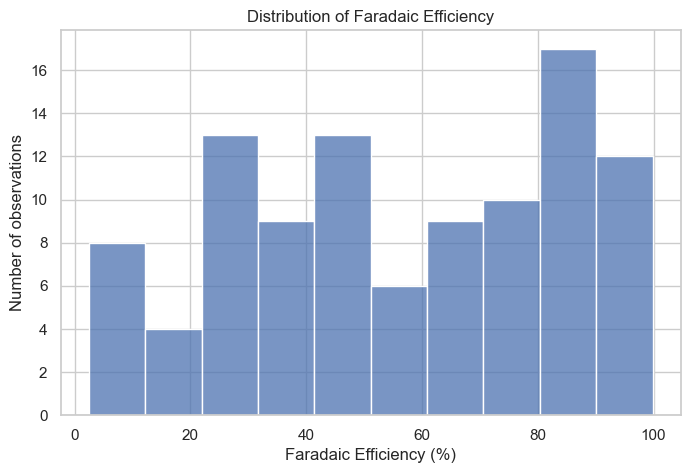

In [57]:
# Plot the distribution of Faradaic efficiency across the populated low-temperature observations.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=low_temp_non_empty,
    x="Faradaic Efficiency (%)",
    bins=10
)

plt.title("Distribution of Faradaic Efficiency")
plt.xlabel("Faradaic Efficiency (%)")
plt.ylabel("Number of observations")
plt.show()

#### **Observation**

Faradaic efficiency is broadly distributed across the low-temperature dataset, with values ranging from very low efficiencies to values close to 100%.

The distribution is not concentrated within a single narrow range. A relatively large number of observations occur at higher Faradaic efficiencies, particularly around the 80–90% region.

Because the dataset combines different catalysts, products, and reported experimental conditions, this histogram is used only to describe the overall spread of Faradaic efficiency values. It does not by itself indicate which catalyst performs best.

#### **4.1.b Current density distribution**

Next, inspect the distribution of current density across the populated low-temperature observations.

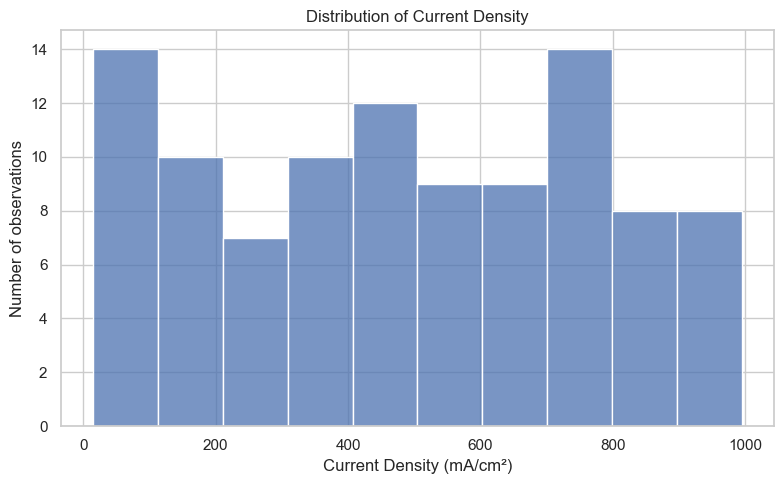

In [58]:
# Plot the distribution of current density across the populated low-temperature observations.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=low_temp_non_empty,
    x="Current Density (mA/cm2)",
    bins=10
)

plt.title("Distribution of Current Density")
plt.xlabel("Current Density (mA/cm²)")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

#### **Observation**

Current density is broadly distributed across the low-temperature dataset, with observations spanning from very low values to nearly **1000 mA/cm²**.

The distribution does not show one narrow dominant range. Instead, observations occur across low, intermediate, and high current densities.

This broad spread indicates that the dataset contains records reported under a wide range of current-density conditions.

Because the dataset combines different catalysts, products, and reported experimental conditions, this histogram is used only to describe the overall distribution of current density and not to compare catalyst performance directly.

#### **4.1.c Applied potential distribution**

Next, inspect the distribution of applied potential across the populated low-temperature observations.

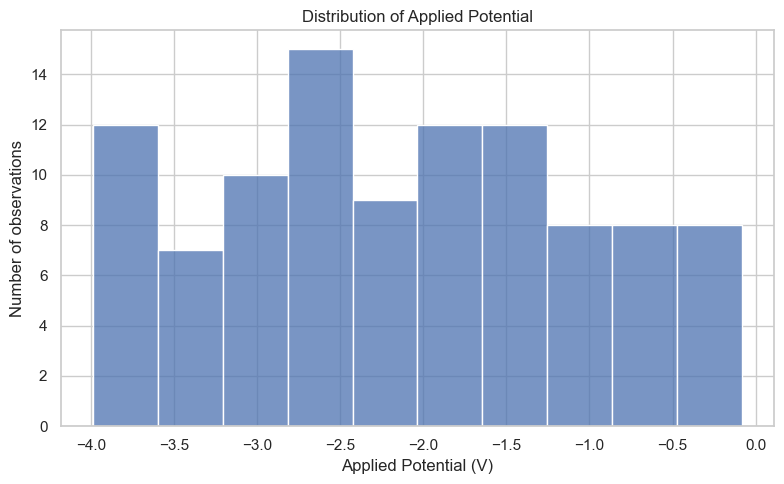

In [59]:
# Plot the distribution of applied potential across the populated low-temperature observations.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=low_temp_non_empty,
    x="Applied Potential (V)",
    bins=10
)

plt.title("Distribution of Applied Potential")
plt.xlabel("Applied Potential (V)")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

#### **Observation**

Applied potential is broadly distributed across the low-temperature dataset, ranging from approximately **−4.0 V to near 0 V**.

The observations occur across the full potential range, with somewhat higher concentrations in parts of the intermediate range, particularly around **−3.0 to −2.4 V** and **−2.0 to −1.3 V**.

Because the dataset combines different catalysts, products, and reported experimental conditions, this distribution is used to describe the overall range of applied potentials rather than to compare catalyst performance directly.

#### **4.1.d Cost distribution**

Next, inspect the distribution of reported cost across the populated low-temperature observations.

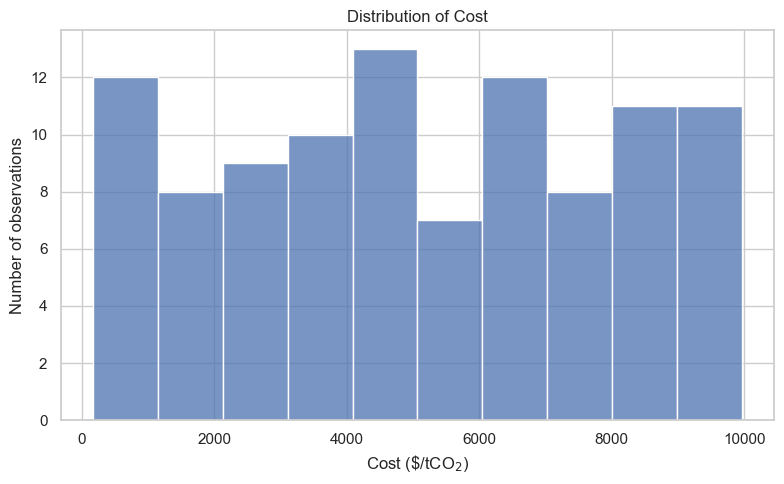

In [60]:
# Plot the distribution of reported cost across the populated low-temperature observations.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=low_temp_non_empty,
    x="Cost ($/tCO2)",
    bins=10
)

plt.title("Distribution of Cost")
plt.xlabel(r"Cost (\$/tCO$_2$)")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

#### **Observation**

Reported cost is broadly distributed across the low-temperature dataset, ranging from a few hundred to nearly **$10,000/tCO<sub>2</sub>**.

The observations occur throughout the cost range without a single narrow region dominating the distribution.

Because the dataset combines different catalysts, products, and reported experimental conditions, this histogram is used to describe the overall spread of reported cost rather than to determine which catalyst system is most economically favourable.

#### **4.1.e Production rate distribution**

Finally, inspect the distribution of production rate across the populated low-temperature observations.

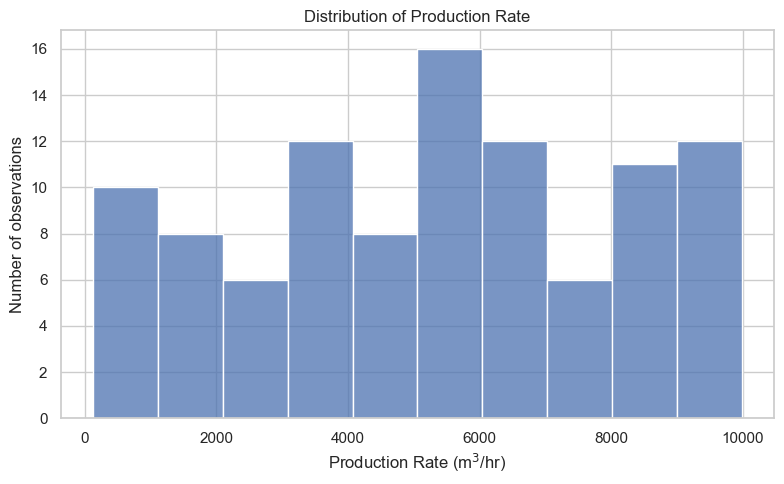

In [61]:
# Plot the distribution of production rate across the populated low-temperature observations.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=low_temp_non_empty,
    x="Production Rate (m3/hr)",
    bins=10
)

plt.title("Distribution of Production Rate")
plt.xlabel(r"Production Rate (m$^3$/hr)")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

#### **Observation**

Production rate is broadly distributed across the low-temperature dataset, with values ranging from relatively low rates to nearly **10,000 m³/hr**.

The observations occur across the full range, with a somewhat higher concentration around approximately **5,000–7,000 m³/hr**.

Because the dataset combines different catalysts, products, and reported experimental conditions, this histogram is used to describe the overall spread of production-rate values rather than to compare catalyst performance directly.

### **4.2 Second experimental dataset**

After inspecting the low-temperature dataset, examine the distributions of the main numerical variables in the second experimental dataset.

#### **4.2.a Faradaic efficiency distribution**

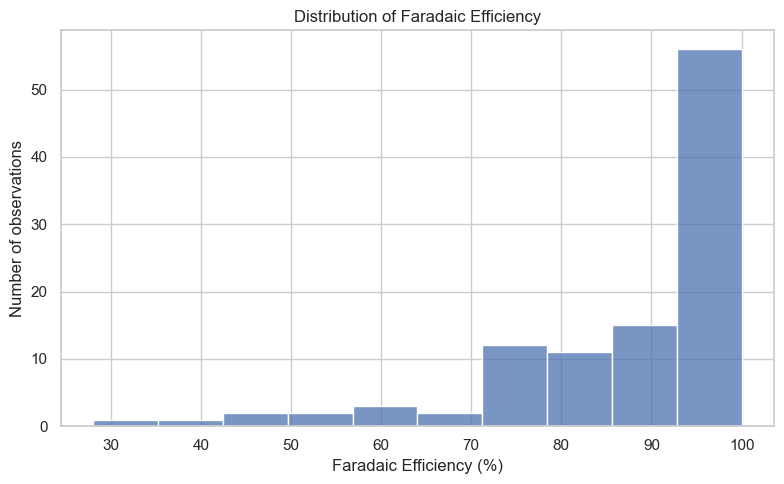

In [62]:
# Plot the distribution of reported Faradaic efficiency values in the second experimental dataset, ignoring rows where FE is missing.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=high_temp_df,
    x="FE  (%)",
    bins=10
)

plt.title("Distribution of Faradaic Efficiency")
plt.xlabel("Faradaic Efficiency (%)")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

#### **Observation**

Reported Faradaic efficiency in the second experimental dataset is strongly concentrated at the higher end of the range.

Most observations with reported FE values fall between approximately **70% and 100%**, with the largest concentration close to **95–100%**.

Only a small number of reported FE values occur below approximately **70%**.

Because Faradaic efficiency is reported for only **105 of the 181 observations**, this histogram represents the FE-reporting subset rather than the full second experimental dataset.

#### **4.2.b Voltage distribution**

Next, inspect the distribution of reported voltage values in the second experimental dataset.

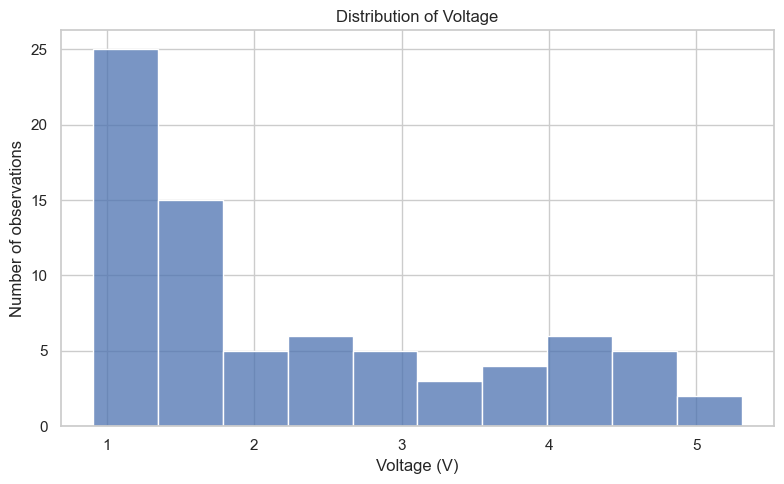

In [63]:
# Plot the distribution of reported voltage values in the second experimental dataset, ignoring rows where voltage is missing.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=high_temp_df,
    x="Voltage(V)",
    bins=10
)

plt.title("Distribution of Voltage")
plt.xlabel("Voltage (V)")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

#### **Observation**

Reported voltage values are concentrated toward the lower end of the observed range.

Most voltage values occur between approximately **1 and 2 V**, with the highest concentration around **1–1.5 V**. Fewer observations are reported at higher voltages, although the dataset extends to values above **5 V**.

Because voltage is reported for only **76 of the 181 observations**, this histogram represents the voltage-reporting subset rather than the full second experimental dataset.

#### **4.2.c Total current density distribution**

Next, inspect the distribution of total current density across the second experimental dataset.

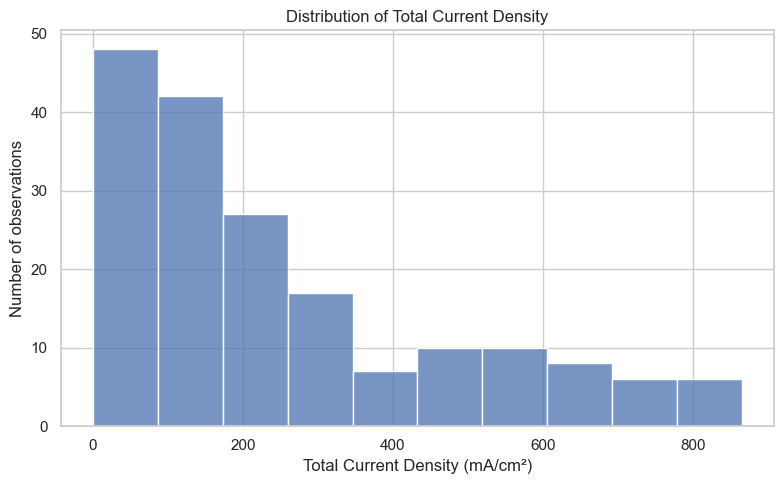

In [64]:
# Plot the distribution of total current density across all observations in the second experimental dataset.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=high_temp_df,
    x="Jtot(mA/cm2)",
    bins=10
)

plt.title("Distribution of Total Current Density")
plt.xlabel("Total Current Density (mA/cm²)")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

#### **Observation**

Total current density is concentrated toward the lower end of the observed range.

Most observations fall below approximately **300 mA/cm²**, with the highest concentration at the lowest current-density values. The number of observations generally decreases as current density increases, although the dataset extends to values above **800 mA/cm²**.

Because total current density is reported for all **181 observations**, this histogram represents the full second experimental dataset.

#### **4.2.d Temperature distribution**

Finally, inspect the distribution of reported temperature across the second experimental dataset.

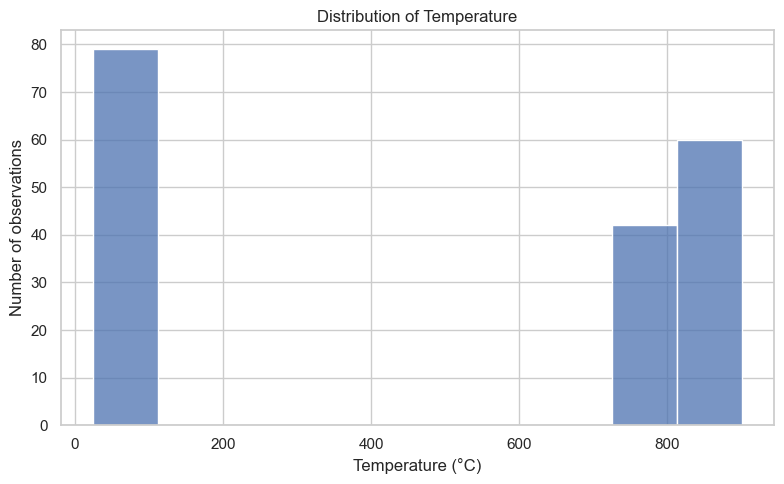

In [65]:
# Plot the distribution of reported temperature across all observations in the second experimental dataset.
plt.figure(figsize=(8, 5))

sns.histplot(
    data=high_temp_df,
    x="T (oC)",
    bins=10
)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of observations")

plt.tight_layout()
plt.show()

#### **Observation**

The temperature distribution shows two clearly separated groups of observations.

One group is concentrated at low temperatures, approximately **25–100 °C**, while the other is concentrated at high temperatures, approximately **750–900 °C**.

There are very few or no observations in the intermediate temperature range.

This confirms that the second experimental dataset contains distinct low- and high-temperature conditions rather than a single continuous temperature range.

The dataset should therefore not be interpreted as exclusively high-temperature.

---
## **5. Categorical columns**

**This is the section that feeds tomorrow.** A column with few distinct values repeated over many rows is a lookup table waiting to happen. Find them.

### **5.1 Low-temperature dataset**

After inspecting the numerical distributions, examine the categorical variables to identify repeated values that may later support relational lookup tables.

#### **5.1.a Number of unique categories**

In [66]:
# Count how many unique catalyst categories are present.
low_temp_non_empty["Catalyst"].nunique()

8

In [67]:
# Count how many unique product categories are present.
low_temp_non_empty["Product"].nunique()

5

#### **Observation**

The low-temperature dataset contains **8 unique catalyst categories** and **5 unique product categories** across 101 populated observations.

Because these categorical values repeat across many experimental records, `Catalyst` and `Product` are potential candidates for separate lookup tables in the relational database.

For example:
- a `catalysts` table could assign each catalyst a unique identifier,
- a `products` table could assign each product a unique identifier,
- the main experiment table could then reference those identifiers using foreign keys.

### **5.2 Second experimental dataset** 

Next, examine the categorical variables in the second experimental dataset to identify repeated values and formatting issues that may affect database design.

#### **5.2.a Number of unique categories**

In [68]:
# Count how many unique catalyst categories are present
# in the second experimental dataset.
high_temp_df["Catalysts"].nunique()

8

In [69]:
# Count how many unique electrolyte categories are present.
high_temp_df["Electrolyte"].nunique()

7

In [70]:
# Count how many unique product categories are present.
high_temp_df["Product.1"].nunique()

1

#### **5.2.b Whitespace verification**

Next, verify whether leading or trailing whitespace changes the number of distinct categories.

In [71]:
# Temporarily remove leading and trailing spaces from
# catalyst labels, then count the remaining unique categories.
# This does not modify the original DataFrame.
high_temp_df["Catalysts"].str.strip().nunique()

7

In [72]:
# Temporarily remove leading and trailing spaces from
# electrolyte labels, then count the remaining unique categories.
# This does not modify the original DataFrame.
high_temp_df["Electrolyte"].str.strip().nunique()

7

#### **Observation**

The second experimental dataset contains repeated catalyst and electrolyte categories across many observations.

The raw data contains **8 catalyst labels**, **7 electrolyte labels**, and **1 product label**.

After temporarily removing leading and trailing whitespace, the number of unique catalyst categories decreases from **8 to 7**. This shows that one apparent catalyst category is a duplicate created by inconsistent whitespace.

The number of unique electrolyte categories remains **7** after whitespace removal. This means whitespace is present in some electrolyte labels, but it does not create additional distinct electrolyte categories.

These formatting inconsistencies should be corrected during data cleaning before the relational database is created.

Because catalyst and electrolyte values repeat across many records, they are potential candidates for separate lookup tables.

The product column contains only one category, `CO`, across all 181 observations, so its role in the final database structure should be considered together with the other experimental dataset rather than based on this dataset alone.

## **6. Research questions**

Based on the exploratory analysis, the following research questions will guide the later SQL analysis and visualisation.

### **6.1 Research question 1**

**How do Faradaic efficiency and current density vary across catalyst–product combinations in the low-temperature dataset?**

**Expectation / Hypothesis:**  
I expect average Faradaic efficiency and current density to differ across catalyst–product combinations.

**Why:**  
Different catalyst–product combinations are associated with different reported performance conditions, so their Faradaic efficiency and current-density behaviour are unlikely to be identical.



### **6.2 Research question 2**

**Which catalyst–product combinations combine above-average Faradaic efficiency and current density with below-average reported cost in the low-temperature dataset?**

**Expectation / Hypothesis:**  
I expect only a subset of catalyst–product combinations to satisfy all three criteria simultaneously.

**Why:**  
High electrochemical performance does not necessarily correspond to lower reported cost. Considering Faradaic efficiency, current density, and cost together allows catalyst–product combinations to be evaluated across multiple performance objectives.




### **6.3 Research question 3**

**How does total current density vary across catalyst–electrolyte combinations in the second experimental dataset?**

**Expectation / Hypothesis:**  
I expect total current density to vary across catalyst–electrolyte combinations rather than being associated with catalyst identity alone.

**Why:**  
The second experimental dataset contains repeated catalyst and electrolyte categories across a broad range of current densities, allowing different catalyst–electrolyte combinations to be compared.




### **6.4 Research question 4**

**How are catalyst, electrolyte, and total current density distributed across the distinct temperature groups in the second experimental dataset?**

**Expectation / Hypothesis:**  
I expect the low- and high-temperature groups to differ not only in temperature, but also in the catalyst and electrolyte systems represented.

**Why:**  
The exploratory analysis identified two clearly separated temperature groups, suggesting that they may represent different types of experimental systems rather than simply the same experiments conducted at different temperatures.

---

## **7. Into Notebook 02**

The exploratory analysis identified several cleaning and preparation tasks that should be completed before building the relational database and performing SQL analysis.

### **7.1 Cleaning tasks**

#### Low-temperature dataset

- Remove the **80 completely empty trailing rows**.
- Standardise column names and scientific unit notation.
- Preserve the **101 populated observations**, since no exact duplicates were found.
- Keep the existing numerical values because the basic validity checks identified no obvious invalid values.

#### Second experimental dataset

- Standardise column names, including:
  - `Catalysts`
  - `Voltage(V)`
  - `Jtot(mA/cm2)`
  - `FE  (%)`
  - `Electrolyte`
  - `Product.1`
  - `T (oC)`
- Remove leading and trailing whitespace from categorical values.
- Resolve the duplicate catalyst category created by inconsistent whitespace.
- Preserve the structured missing values in `Voltage(V)` and `FE  (%)` rather than automatically dropping or imputing them.
- Preserve both low- and high-temperature observations, since the low-temperature subset appears to represent a meaningful part of the dataset rather than isolated errors.

### **7.2 Planned database structure**

Based on the EDA, the cleaned data is expected to support at least the following relational tables:

- `catalysts` — unique catalyst categories
- `products` — unique CO<sub>2</sub>RR product categories
- `electrolytes` — unique electrolyte categories
- `low_temp_experiments` — measurements from the low-temperature experimental data block
- `second_experiments` — measurements from the second experimental data block

The experiment tables will reference the relevant lookup tables using primary and foreign keys.

The exact schema, keys, and relationships will be finalised in Notebook 02 after the cleaning steps are completed.

---